# LSTM Training and Evaluation
notebook pour entrainer et evaluer les LSTM par type (REF/CONG/ETUVE)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
import os

# dossier ou sont les donnee preparee
DATA_FOLDER = "data/processed"
MODEL_FOLDER = "models"
os.makedirs(MODEL_FOLDER, exist_ok=True)

print("import ok")

import ok


## Etape 1 : charge les donnee preparee

In [2]:
# charge les donnee pour les 3 type
TYPES = ["ETUVE", "REF", "CONG"]
data = {}

for device_type in TYPES:
    X = np.load(f"{DATA_FOLDER}/X_{device_type}.npy")
    y = np.load(f"{DATA_FOLDER}/y_{device_type}.npy")
    
    # rajoute une dimension pour keras (nb example, seq_length, 1 feature)
    X = X.reshape((X.shape[0], X.shape[1], 1))
    
    data[device_type] = {"X": X, "y": y}
    print(f"type {device_type}")
    print(f"X shape {X.shape}")
    print(f"y shape {y.shape}")
    print("")

type ETUVE
X shape (88135, 60, 1)
y shape (88135, 1)

type REF
X shape (352540, 60, 1)
y shape (352540, 1)

type CONG
X shape (333818, 60, 1)
y shape (333818, 1)



## Etape 2 : split train/validation

In [3]:
# split les donnee en train/val (80/20)
# PAS de shuffle car c est du temporel
VAL_SPLIT = 0.2

for device_type in TYPES:
    X = data[device_type]["X"]
    y = data[device_type]["y"]
    
    split_idx = int(len(X) * (1 - VAL_SPLIT))
    X_train = X[:split_idx]
    y_train = y[:split_idx]
    X_val = X[split_idx:]
    y_val = y[split_idx:]
    
    data[device_type]["X_train"] = X_train
    data[device_type]["y_train"] = y_train
    data[device_type]["X_val"] = X_val
    data[device_type]["y_val"] = y_val
    
    print(f"type {device_type}")
    print(f"train : {len(X_train)} exemple, val : {len(X_val)} exemple")
    print("")

type ETUVE
train : 70508 exemple, val : 17627 exemple

type REF
train : 282032 exemple, val : 70508 exemple

type CONG
train : 267054 exemple, val : 66764 exemple



## Etape 3 : construit le model lstm
archi : 1 couche LSTM + 1 couche Dense qui sort 1 valeur

In [4]:
def build_model(seq_length):
    # seq_length = 60 (nombre de minute dans la sequence)
    model = keras.Sequential([
        layers.Input(shape=(seq_length, 1)),
        # 32 neurone dans le LSTM
        layers.LSTM(32),
        # couche de sortie, 1 seule valeur = temperature normalise predite
        layers.Dense(1),
    ])
    
    model.compile(optimizer="adam", loss="mse")
    return model

# construit un model de reference pour voir l archi
seq_length = data["ETUVE"]["X_train"].shape[1]
model_test = build_model(seq_length)
model_test.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

## Etape 4 : entraine les models
boucle sur les 3 type et entraine chacun

In [5]:
EPOCHS = 10
BATCH_SIZE = 64

histories = {}

for device_type in TYPES:
    print(f"entrainement pour le type {device_type}")
    
    X_train = data[device_type]["X_train"]
    y_train = data[device_type]["y_train"]
    X_val = data[device_type]["X_val"]
    y_val = data[device_type]["y_val"]
    
    seq_length = X_train.shape[1]
    model = build_model(seq_length)
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1
    )
    
    histories[device_type] = history
    
    # sauvegarde du model
    model_path = f"{MODEL_FOLDER}/lstm_{device_type}.keras"
    model.save(model_path)
    print(f"model sauvegarde : {model_path}")
    print("")

entrainement pour le type ETUVE
Epoch 1/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 53s 45ms/step - loss: 0.0136 - val_loss: 0.0021
Epoch 2/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 60s 54ms/step - loss: 0.0031 - val_loss: 8.8946e-04
Epoch 3/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 58s 52ms/step - loss: 0.0026 - val_loss: 0.0010
Epoch 4/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 46s 42ms/step - loss: 0.0026 - val_loss: 0.0028
Epoch 5/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - loss: 0.0025 - val_loss: 9.1417e-04
Epoch 6/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 44s 40ms/step - loss: 0.0025 - val_loss: 8.1446e-04
Epoch 7/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - loss: 0.0025 - val_loss: 0.0016
Epoch 8/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - loss: 0.0025 - val_loss: 8.3414e-04
Epoch 9/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - loss: 0.0025 - val_loss: 7.8312e-04
Epoch 10/10
1102/1102 ━━━━━━━━━━━━━━━━━━━━ 47s 42ms/step - loss: 0.0025 - val_loss: 8.0763e-04
model sauvegarde : models/lstm_ETUVE.keras


## Etape 5 : visualise la courbe de loss par type

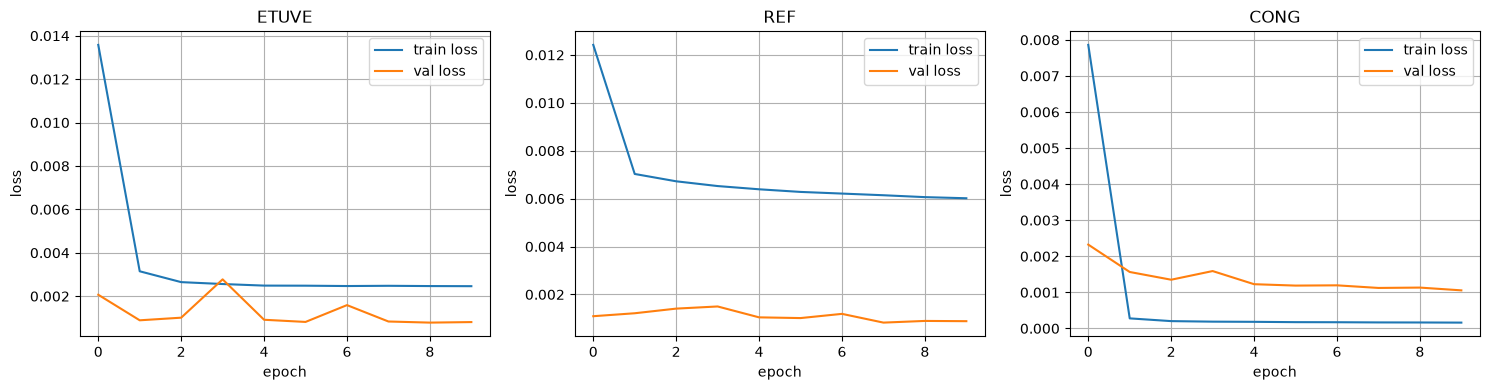

courbe de loss traceee


In [ ]:
# trace les courbe de loss pour les 3 type
fig, axes = plYt.subplots(1, 3, figsize=(15, 4))

for idx, device_type in enumerate(TYPES):
    history = histories[device_type]
    
    axes[idx].plot(history.history["loss"], label="train loss")
    axes[idx].plot(history.history["val_loss"], label="val loss")
    axes[idx].set_title(f"{device_type}")
    axes[idx].set_xlabel("epoch")
    axes[idx].set_ylabel("loss")
    axes[idx].legend()
    axes[idx].grid(True)

plt.tight_layout()
plt.show()

print("courbe de loss traceee")

## Etape 6 : charge les model et fait des prediction

In [7]:
# recharge les model depuis le disque (pour pouvoir les reutiliser apres)
models = {}

for device_type in TYPES:
    model_path = f"{MODEL_FOLDER}/lstm_{device_type}.keras"
    models[device_type] = keras.models.load_model(model_path)
    print(f"model {device_type} charge")

print("")

model ETUVE charge
model REF charge
model CONG charge



In [8]:
# fait des prediction sur la validation set pour chaque type
predictions = {}

for device_type in TYPES:
    X_val = data[device_type]["X_val"]
    y_val = data[device_type]["y_val"]
    
    model = models[device_type]
    y_pred = model.predict(X_val, verbose=0)
    
    # calcul l erreur de prediction
    error = np.abs(y_val - y_pred)
    
    predictions[device_type] = {
        "y_true": y_val,
        "y_pred": y_pred,
        "error": error
    }
    
    print(f"type {device_type}")
    print(f"erreur moyenne : {error.mean():.6f}")
    print(f"erreur max : {error.max():.6f}")
    print(f"erreur median : {np.median(error):.6f}")
    print("")

type ETUVE
erreur moyenne : 0.013726
erreur max : 0.268549
erreur median : 0.002950

type REF
erreur moyenne : 0.017750
erreur max : 0.622189
erreur median : 0.009478

type CONG
erreur moyenne : 0.018137
erreur max : 4.160707
erreur median : 0.012096



## Etape 7 : charge les donnee avec baseline et zscore pour comparer

In [9]:
# charge le fichier avec baseline et zscore deja calcule
all_data = pd.read_csv(f"{DATA_FOLDER}/all_data_with_zscore.csv", parse_dates=["Time"])

print("donnee charge")
print("shape", all_data.shape)
print("colonnes", all_data.columns.tolist())

donnee charge
shape (793755, 12)
colonnes ['Time', 'Temperature', 'humidity', 'battery', 'device_id', 'type', 'temp_diff', 'suspicious_flat', 'sensor_group', 'baseline_anomaly', 'zscore', 'zscore_anomaly']


## Etape 8 : compare LSTM vs baseline vs zscore sur les excursion connu

In [10]:
# fenetre d excursion connu
excursion_windows = {
    "44B0C6": ("2026-06-20", "2026-06-27"),
    "5F6A6A": ("2026-07-13", "2026-07-19"),
}

# pour chaque device avec excursion, regarde combien baseline et zscore flag
for device_id, (start, end) in excursion_windows.items():
    g = all_data[all_data["device_id"] == device_id]
    mask_window = (g["Time"] >= start) & (g["Time"] <= end)
    g_window = g[mask_window]
    
    print(f"device {device_id}")
    print(f"periode {start} a {end}")
    print(f"nb ligne {len(g_window)}")
    print(f"baseline flag {g_window['baseline_anomaly'].sum()}")
    print(f"zscore flag {g_window['zscore_anomaly'].sum()}")
    print("")

device 44B0C6
periode 2026-06-20 a 2026-06-27
nb ligne 10081
baseline flag 1455
zscore flag 98

device 5F6A6A
periode 2026-07-13 a 2026-07-19
nb ligne 8641
baseline flag 197
zscore flag 176



## Etape 9 : resume des resultat
comparaison loss training/val par type

In [11]:
# affiche un resume des resultat d entrainement
print("resume de l entrainement")
print("")

for device_type in TYPES:
    history = histories[device_type]
    
    train_loss_init = history.history["loss"][0]
    train_loss_final = history.history["loss"][-1]
    val_loss_init = history.history["val_loss"][0]
    val_loss_final = history.history["val_loss"][-1]
    
    print(f"type {device_type}")
    print(f"train loss : {train_loss_init:.6f} -> {train_loss_final:.6f}")
    print(f"val loss : {val_loss_init:.6f} -> {val_loss_final:.6f}")
    print("")

resume de l entrainement

type ETUVE
train loss : 0.013578 -> 0.002461
val loss : 0.002067 -> 0.000808

type REF
train loss : 0.012418 -> 0.006016
val loss : 0.001091 -> 0.000884

type CONG
train loss : 0.007861 -> 0.000161
val loss : 0.002323 -> 0.001055



## Etape 10 : visualise quelques prediction vs vraie valeur
pour ETUVE en exemple

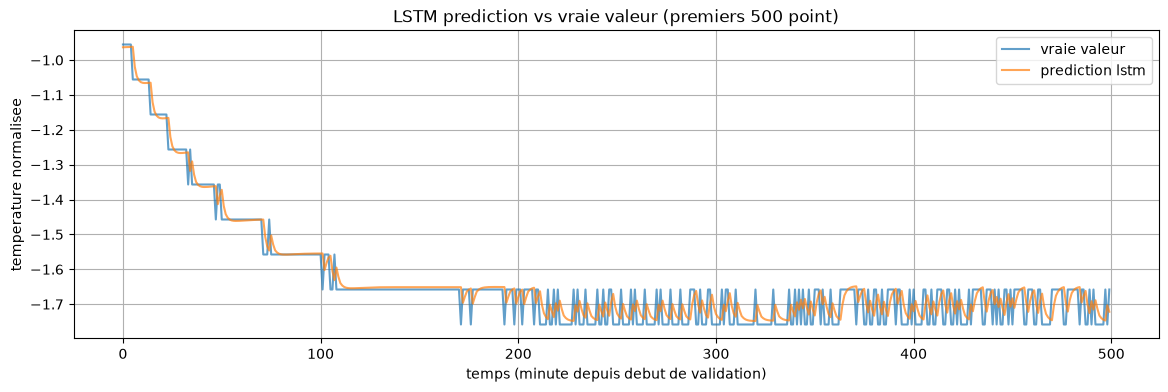

In [12]:
# trace les 500 premiere prediction de ETUVE pour voir si le modele suit la vraie courbe
device_type = "ETUVE"
y_true = predictions[device_type]["y_true"][:500]
y_pred = predictions[device_type]["y_pred"][:500]

plt.figure(figsize=(14, 4))
plt.plot(y_true, label="vraie valeur", alpha=0.7)
plt.plot(y_pred, label="prediction lstm", alpha=0.7)
plt.title(f"LSTM prediction vs vraie valeur (premiers 500 point)")
plt.xlabel("temps (minute depuis debut de validation)")
plt.ylabel("temperature normalisee")
plt.legend()
plt.grid(True)
plt.show()